# What's the sales distribution across customer segments (Consumer, Corporate, Home Office)?

### Methodology

- Filtering the data for the current year
- Aggregating Sales for each Customer Segment
- Visualizing the data

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('sample_superstore.xls')

current_month = pd.Timestamp.today().month
df = df[
    (df['Order Date'].dt.year == 2026) &
    (df['Order Date'].dt.month <= current_month)
]
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
6815,6816,US-2026-151750,2026-01-01,2026-01-05,Standard Class,JM-15250,Janet Martin,Consumer,United States,Huntsville,...,77340,Central,FUR-CH-10003199,Furniture,Chairs,Office Star - Contemporary Task Swivel Chair,310.744,4,0.3,-26.6352
6816,6817,US-2026-144463,2026-01-01,2026-01-05,Standard Class,SC-20725,Steven Cartwright,Consumer,United States,Los Angeles,...,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
6817,6818,US-2026-151750,2026-01-01,2026-01-05,Standard Class,JM-15250,Janet Martin,Consumer,United States,Huntsville,...,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815
6818,6819,US-2026-107503,2026-01-01,2026-01-06,Standard Class,GA-14725,Guy Armstrong,Consumer,United States,Lorain,...,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
6819,6820,US-2026-151750,2026-01-01,2026-01-05,Standard Class,JM-15250,Janet Martin,Consumer,United States,Huntsville,...,77340,Central,OFF-AP-10004708,Office Supplies,Appliances,Fellowes Superior 10 Outlet Split Surge Protector,15.224,2,0.8,-38.8212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8938,8939,US-2026-120908,2026-09-30,2026-10-02,First Class,BF-10975,Barbara Fisher,Corporate,United States,Philadelphia,...,19120,East,OFF-LA-10004677,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters w...,20.664,7,0.2,6.9741
8939,8940,US-2026-144225,2026-09-30,2026-10-02,Second Class,CC-12475,Cindy Chapman,Consumer,United States,Baltimore,...,21215,East,OFF-PA-10000062,Office Supplies,Paper,Green Bar Computer Printout Paper,164.880,3,0.0,80.7912
8940,8941,US-2026-147452,2026-09-30,2026-10-03,First Class,CS-11845,Cari Sayre,Corporate,United States,Seattle,...,98103,West,OFF-PA-10001838,Office Supplies,Paper,Adams Telephone Message Book W/Dividers/Space ...,11.760,2,0.0,5.7624
8941,8942,US-2026-147452,2026-09-30,2026-10-03,First Class,CS-11845,Cari Sayre,Corporate,United States,Seattle,...,98103,West,OFF-PA-10004039,Office Supplies,Paper,Xerox 1882,167.940,3,0.0,82.2906


In [8]:
df_segments = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
df_segments

Segment
Consumer       211310.8571
Corporate      152289.0682
Home Office     94863.2849
Name: Sales, dtype: float64

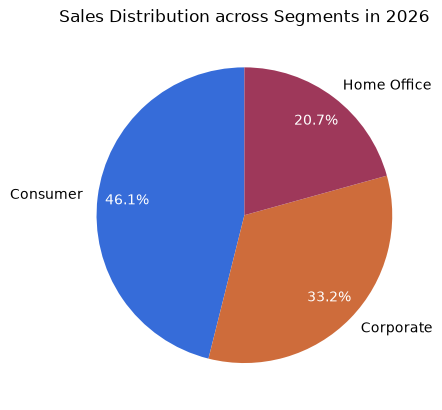

In [33]:
fig = plt.figure(facecolor='white')

wedges, texts, autotexts = plt.pie(
    df_segments,
    labels=['Consumer', 'Corporate', 'Home Office'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
)

for text in texts:
    text.set_color('black')

for autotext in autotexts:
    autotext.set_color('white')

plt.title('Sales Distribution across Segments in 2026', color='black')
plt.show()